# Example 3 -- Cubic phase gate injection via a non-unit-gain teleportation gadget

A more elaborate variant `cubic_phase_injection.ipynb`: the input mode is first mixed with a zero-phase ancilla on a 50:50 beamsplitter (a gain-matching step), then coupled to the cubic-phase ancilla through *two* cup-cap contractions sandwiching an extra squeezing gate (a
non-unit-gain correction), and finally three measurement/feedforward-correction legs. The paper's
claim: despite all the extra machinery -- two beamsplitters, an extra squeeze, three separate
measurement outcomes (`m1`, `m2`) and one feedforward parameter (`lambda1`) -- this still reduces
to a *single* cubic-phase spider whose phase is a polynomial in those measurement outcomes.

This notebook runs the reduction two ways: 

- rule by rule , so each rewrite rule's own individual contribution is visible, 

- then in one call via `optimize()`. 

In [1]:
from sympy import pi, I, symbols
from math import sqrt
from sympy import sqrt as sy_sqrt

from cvzx.ir.base import CompositionDiagram, ContractedDiagram, PSpider, QSpider, TensorDiagram, ZxPoly, flatten_composition, flatten_tensor
from cvzx.ir.gates import BeamsplitterGate, DisplacementGate, PhaseRotationGate, SqueezingGate
from cvzx.passes.optimize import optimize
from cvzx.passes.normalize import normalize_diagram
from cvzx.visualization.core import visualize

zero_phase = ZxPoly({})

## Build the diagram

- **Stage 0**: input mode (identity wire) + a zero-phase ancilla `P(0,1,0)` + the cubic-phase
  ancilla `Q(0,1,gamma*x**3)` whose phase we're injecting.
- **Stage 1**: a 50:50 beamsplitter mixes [input, zero-phase ancilla] (a gain-matching step so the
  cubic-phase ancilla couples in with the right weight below); the cubic-phase ancilla itself
  passes straight through this stage untouched.
- **Stage 2**: one beamsplitter output passes through an extra `SqueezingGate(sqrt(2))`; the other passes through a *second* 50:50
  beamsplitter, which is what actually couples this mode to the cubic-phase ancilla.
- **Stage 3**: three parallel legs -- a `DisplacementGate` fed forward from `meas2`'s outcome, a
  `PhaseRotationGate`-then-measure leg fed forward from `meas1`'s outcome, and a bare measurement
  leg. Each feedforward gate's own phase depends symbolically on the measurement it's conditioned
  on (`param_measurement_map`), which is why the final result below is a genuine *function* of
  `m1`/`m2`, not a single fixed number -- exactly as a real feedforward-corrected teleportation
  gadget would be.

The top-level `CompositionDiagram`'s `connectivity` argument (the second positional argument)
cross-wires stage1's second output into stage2's *third* slot and stage1's third output (the
straight-through cubic-phase ancilla) into stage2's *second* slot -- i.e. it's what actually
routes "the ancilla" to "the beamsplitter that couples to it," rather than the stages lining up
mode-for-mode in numeric order.

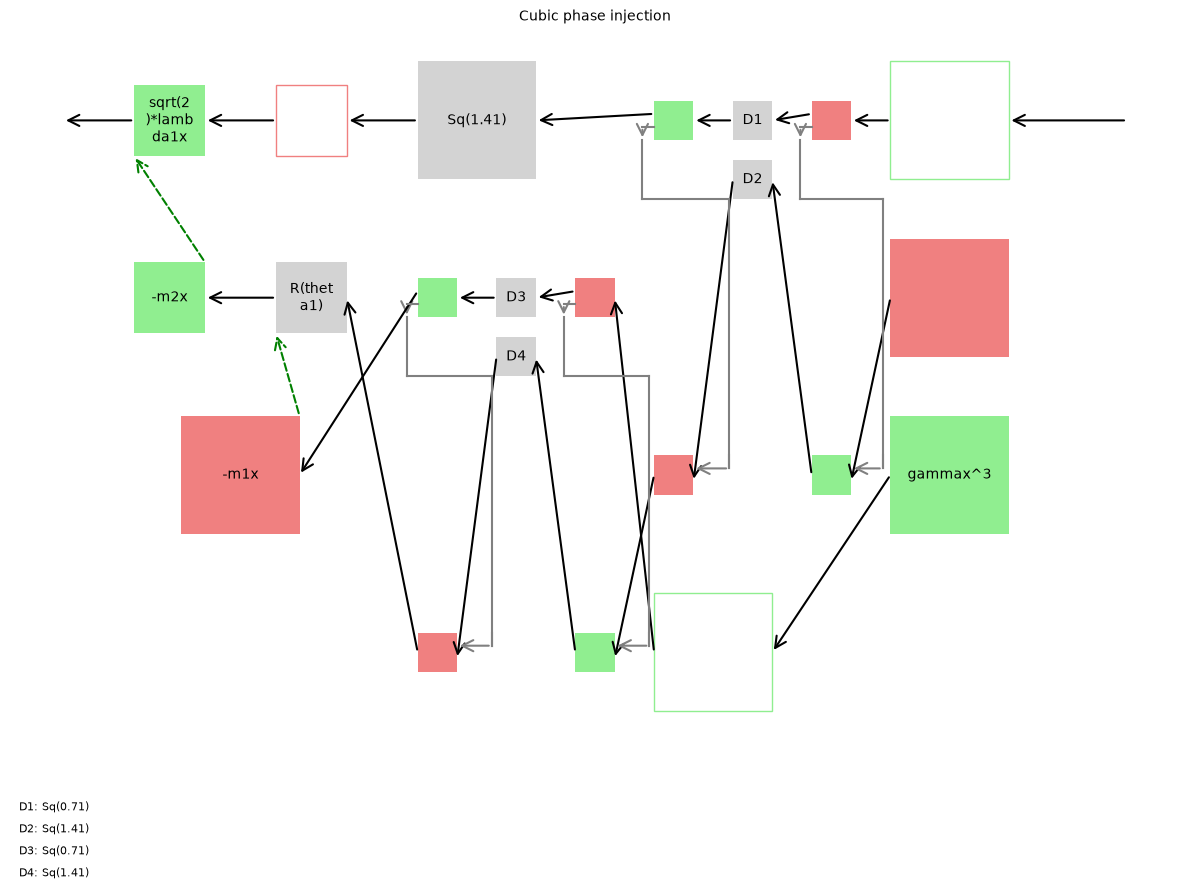

In [2]:
m1, m2, theta1, lambda1, gamma = symbols("m1 m2 theta1 lambda1 gamma", real=True)
# The two measurement effects. Each is a bare (1, 0) terminal spider whose own phase
# (-m1*x / -m2*x) records "this leg's measurement outcome is called m1 / m2" -- the
# feedforward gates below reference `meas1.id`/`meas2.id` to say which measurement they
# depend on, and `{m1: {meas1.id}}` to say which of their own symbols came from it.
meas1 = PSpider(1, 0, ZxPoly({1: -m1}), True)
meas2 = QSpider(1, 0, ZxPoly({1: -m2}),True)

stage0 = TensorDiagram([
    QSpider(1, 1, zero_phase),               # the input mode, untouched so far
    PSpider(0, 1, zero_phase),                # a fresh zero-phase ancilla for the gain-matching beamsplitter
    QSpider(0, 1, ZxPoly({3: gamma}), True),  # the cubic-phase ancilla carrying the phase we want to inject
])
stage1 = TensorDiagram([
    BeamsplitterGate(pi / 4).expand(),  # mixes [input, ancilla] -- expand() turns the compact
                                         # gate into its actual Contract/Squeeze/Contract spider decomposition
    QSpider(1, 1, zero_phase),          # the cubic-phase ancilla passes straight through this stage
])

stage2 = TensorDiagram([
    SqueezingGate(sqrt(2)),             # the non-unit-gain correction (see the markdown above)
    BeamsplitterGate(pi / 4).expand(),  # the beamsplitter that actually couples this mode to the cubic-phase ancilla
])

stage3 = TensorDiagram([
    # Feedforward displacement: its own amount is I*lambda1, but it's *conditioned* on meas2's
    # outcome (measurement_ids={meas2.id}) and lambda1 is tagged as coming from that measurement
    # (param_measurement_map={lambda1: {meas2.id}}) -- this is what lets TerminalAbsorptionRule/
    # ChainReductionRule later fold it into the surviving spider's phase as a genuine function of
    # the measurement outcome, not just a fixed constant.
    DisplacementGate(I * lambda1, True, True, {meas2.id}, {lambda1: {meas2.id}}).expand(),
    # A phase rotation (similarly fed forward from meas1) immediately followed by meas2's own measurement.
    CompositionDiagram([PhaseRotationGate(theta1, True, True, {meas1.id}, {theta1: {meas1.id}}), meas2]),
    meas1,  # the bare measurement leg
])
# The connectivity dict here is what actually routes stage1's outputs into stage2's inputs in the
# non-trivial order described above -- see the markdown cell for exactly which wire goes where.
diag = CompositionDiagram([stage0, stage1, stage2, stage3], {0: {0: 0, 1: 1, 2: 2}, 1: {0: 0, 1: 2, 2: 1}, 2: {0: 0, 1: 2, 2: 1}})
fig = visualize(diag, "Cubic phase injection")

## The paper's claimed reduced form

The paper's claim is that, however elaborate the gadget above looks, it reduces to a single
cubic-phase spider whose phase is a polynomial in `x` -- with the two measurement outcomes `m1`,
`m2` and the feedforward parameter `lambda1` folded into that polynomial's *coefficients* (`alpha`,
`beta` below), not left as separate floating pieces of the diagram. Reaching exactly this shape is
what both the incremental rule-by-rule pipeline and `optimize()` are checked against later in this
notebook.

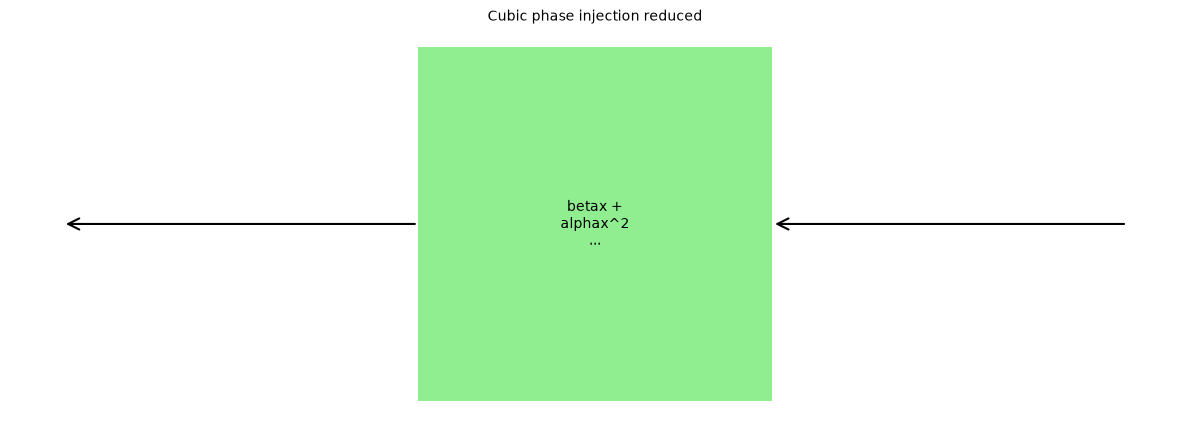

In [3]:
alpha, beta= symbols("alpha beta", real=True)
diag_reduced = QSpider(1, 1, ZxPoly({1: beta, 2: alpha, 3: gamma / (2 * sy_sqrt(2))}), True)
fig = visualize(diag_reduced, "Cubic phase injection reduced")

In [4]:
diag_reduced.phase

beta·x + alpha·x^2 + sqrt(2)*gamma/4·x^3

The phase of the final spider is $\frac{\gamma}{2\sqrt(2)} + \alpha x^2 + \beta x$, where $\alpha$ and $\beta$
are themselves affine in $\gamma$ functions of the measurement outcomes $m_1$, $m_2$, $\theta_1$, and
the feedforward parameter $\lambda_1$ -- the leading $x^3$ coefficient $\frac{\gamma}{2\sqrt(2)})$ is a *fixed* number,
independent of any measurement outcome, exactly as the original cubic-phase ancilla's own $\gamma x^3$ phase was.

## Run the optimization pipeline incrementally

`optimize()` (further below) runs every rewrite rule to a fixed point automatically, in a loop --
useful once you trust it, but opaque about *which* rule did *what*. Here we apply the same rules
one at a time instead, so each one's own individual contribution stays visible:

- **`CopyRule`** fans a measurement's phase out through the adjacent copy spider its own
  contraction leaves it wired to, so each of that contraction's two *kept* (external) legs
  separately carries a copy of the measurement's phase.
- **`FusionRule`** fuses same-color spiders that a previous step (`CopyRule`'s own fan-out, or an
  earlier fusion) left directly adjacent -- including, via its `bare_cap_fusion`-adjacent
  "intrinsic gate" special case, collapsing a bare state/effect that a contraction's own internal
  wiring already fully consumes directly into its partner spider.
- **`TerminalAbsorptionRule`** absorbs a squeezing/rotation/displacement gate's phase into an
  adjacent terminal spider's own phase, and (via its `bare_cap_fusion` match kind) also collapses
  a `ContractedDiagram` whose one half is *already* a bare, fully-internal terminal directly into
  its surviving partner.
- **`VoidPortPruningRule`** trims a spider's port when it's wired straight to a `VoidDiagram` --
  bookkeeping debris a cross-container fold like the ones above routinely leaves behind -- which
  is what exposes several of the further fusions/absorptions below.
- **`ChainReductionRule`**'s commute-and-fuse logic is what folds the very last
  squeezing gate into the combined spider's phase (by scaling the crossed spider's phase variable)
  and then fuses the result with the neighbor it lands next to -- the specific move that produces
  the final answer's exact match to the paper's closed form.

Several of these steps call `normalize_diagram()` first: it re-flattens the diagram's
`Tensor`/`Compose` nesting into one canonical form so same-row spiders become direct composition
siblings again, which is what lets the next rule's own match actually find them.

In [5]:
from cvzx.backends.nx.rules import CopyRule, TerminalAbsorptionRule, FusionRule, ChainReductionRule, VoidPortPruningRule
from cvzx.backends.nx.graph import to_diagram, to_graph

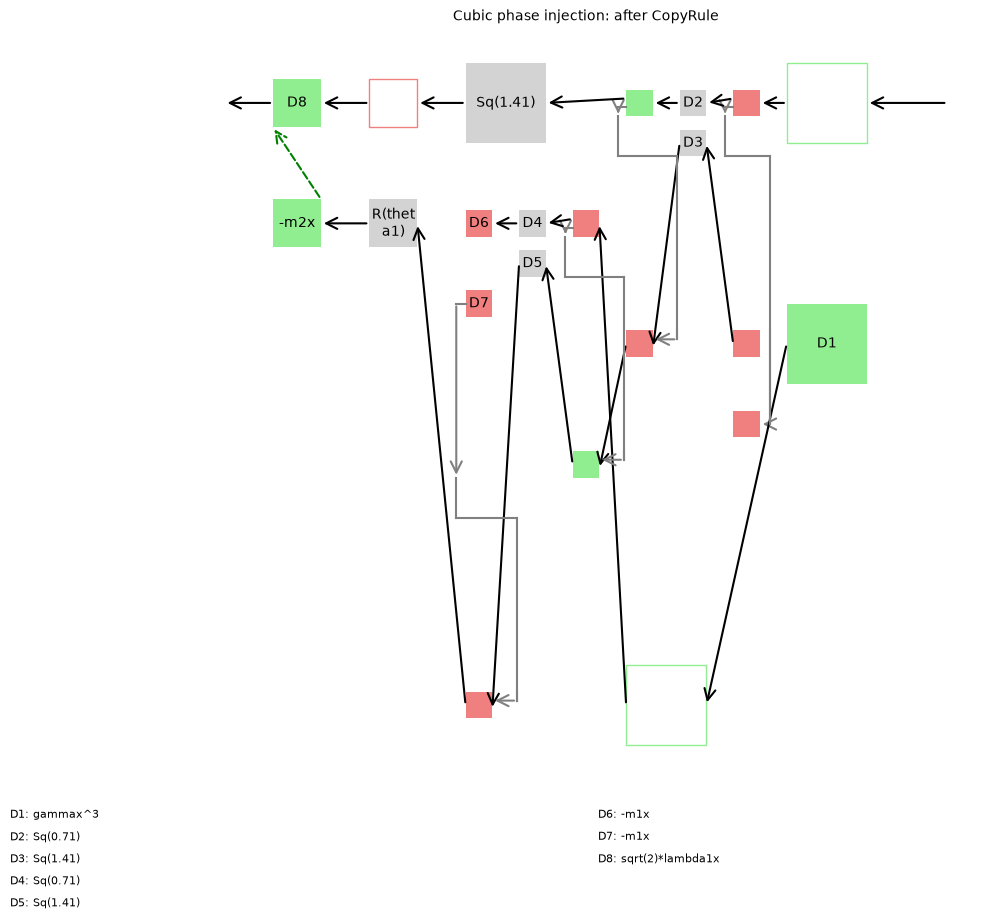

In [6]:
# CopyRule fans meas1's and meas2's own phase out through the copy spider each one's
# contraction already leaves it wired to -- 2 matches, one per measurement.
copy_rule = CopyRule()
graph_after_copy = to_graph(diag)
copy_rule.apply_rule(graph_after_copy)
diag_after_copy = to_diagram(graph_after_copy)
fig_after_copy = visualize(diag_after_copy, "Cubic phase injection: after CopyRule")

### 1. Fusion Rule

Fuses the same-color spider pairs CopyRule's own fan-out just placed directly adjacent.

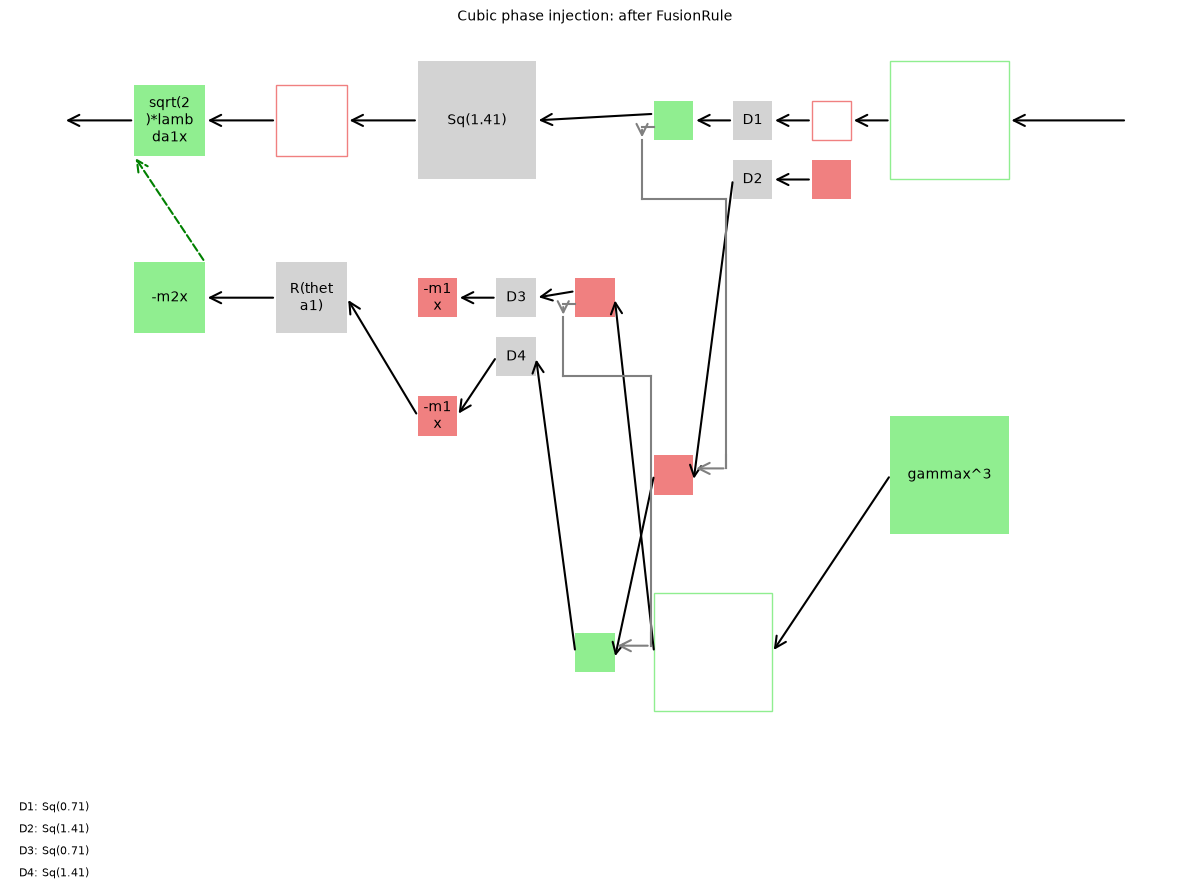

In [7]:
fusion_rule_again = FusionRule()
graph_after_fusion = to_graph(diag_after_copy)

fusion_rule_again.apply_rule(graph_after_fusion)

diag_after_fusion = to_diagram(graph_after_fusion)
fig_after_fusion = visualize(diag_after_fusion, "Cubic phase injection: after FusionRule")

### 2. TerminalAbsorptionRule

Absorbs the beamsplitters' own squeezing-gate decomposition into the terminals/spiders they're now adjacent to (3 separate absorptions).

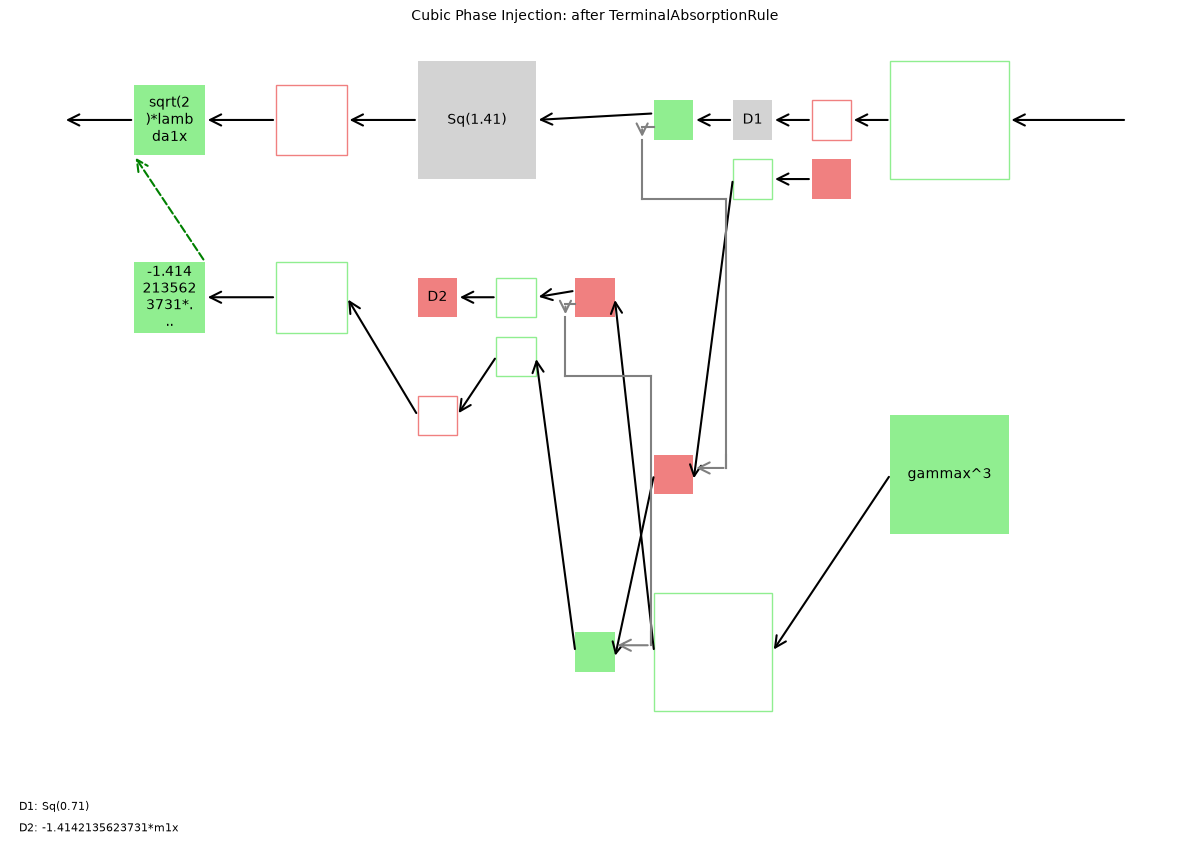

In [8]:
absorption_rule = TerminalAbsorptionRule(True)
graph_after_absorption = to_graph(diag_after_fusion)
absorption_rule.apply_rule(graph_after_absorption)

diag_after_absorption = to_diagram(graph_after_absorption)
fig_after_absorption = visualize(diag_after_absorption, "Cubic Phase Injection: after TerminalAbsorptionRule")

### 3. Fusion Rule

More same-color fusion, exposed by the absorptions just above.

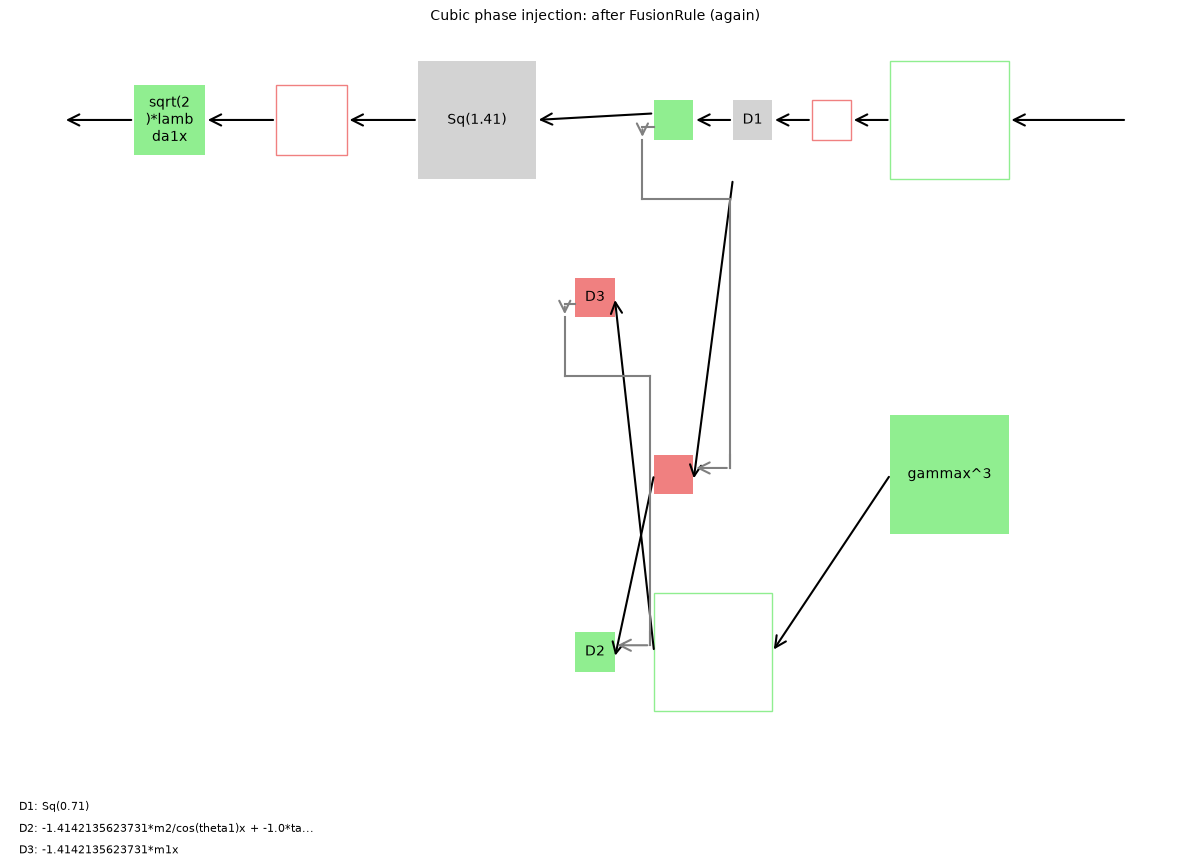

In [9]:
fusion_rule_again = FusionRule()
graph_after_fusion2 = to_graph(diag_after_absorption)

fusion_rule_again.apply_rule(graph_after_fusion2)

diag_after_fusion2 = to_diagram(graph_after_fusion2)
fig_after_fusion2 = visualize(diag_after_fusion2, "Cubic phase injection: after FusionRule (again)")

### 4. TerminalAbsorptionRule

TerminalAbsorptionRule's `bare_cap_fusion` case: one of the two remaining ContractedDiagrams now has a half that's already a bare, fully-internal terminal -- it collapses directly into its partner spider, and the ContractedDiagram wrapper disappears.


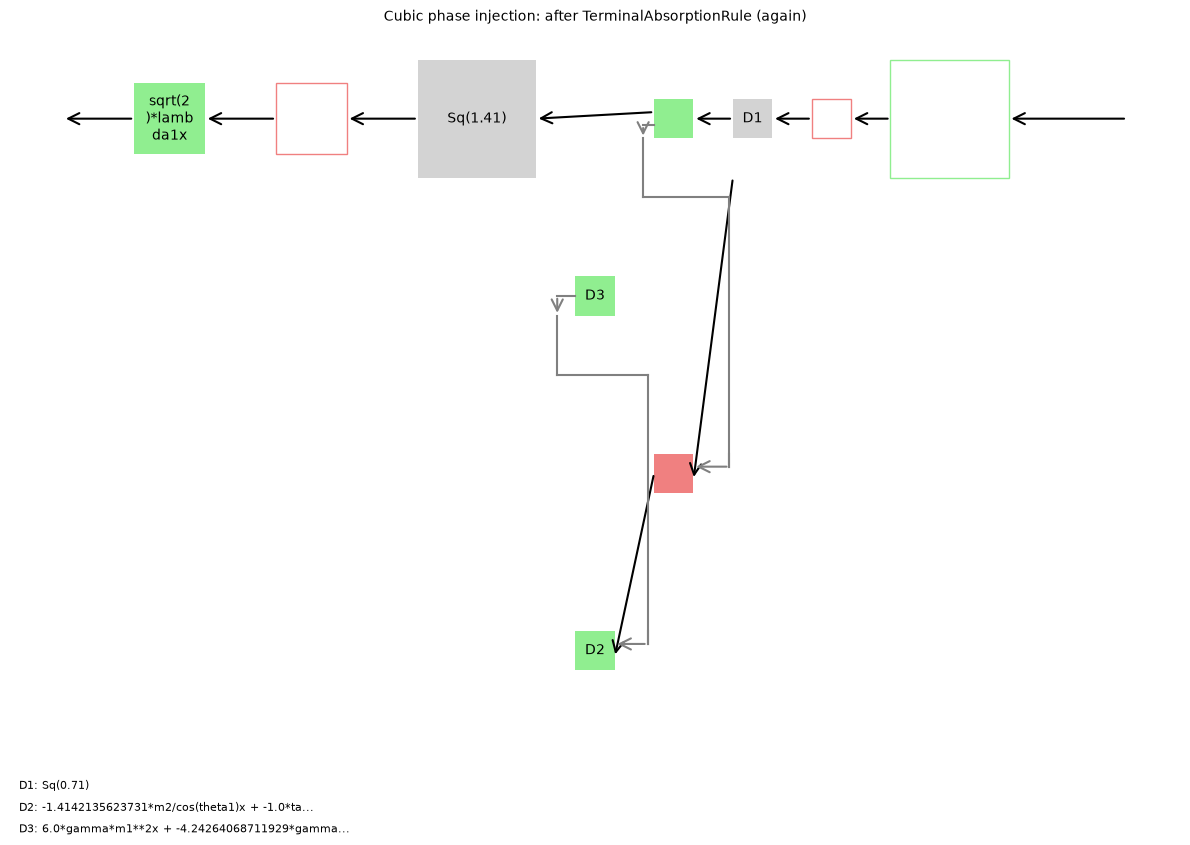

In [10]:
absorption_rule_again = TerminalAbsorptionRule(True)
graph_after_absorption2 = to_graph(diag_after_fusion2)
absorption_rule_again.apply_rule(graph_after_absorption2)
diag_after_absorption2 = to_diagram(graph_after_absorption2)
fig_after_absorption2 = visualize(diag_after_absorption2, "Cubic phase injection: after TerminalAbsorptionRule (again)")

### 5. FusionRule

Nothing new to fuse yet at this exact point -- kept for symmetry with the rest of the incremental pipeline (this cell is a genuine no-op match-wise until VoidPortPruningRule, next, exposes the next round of adjacency).

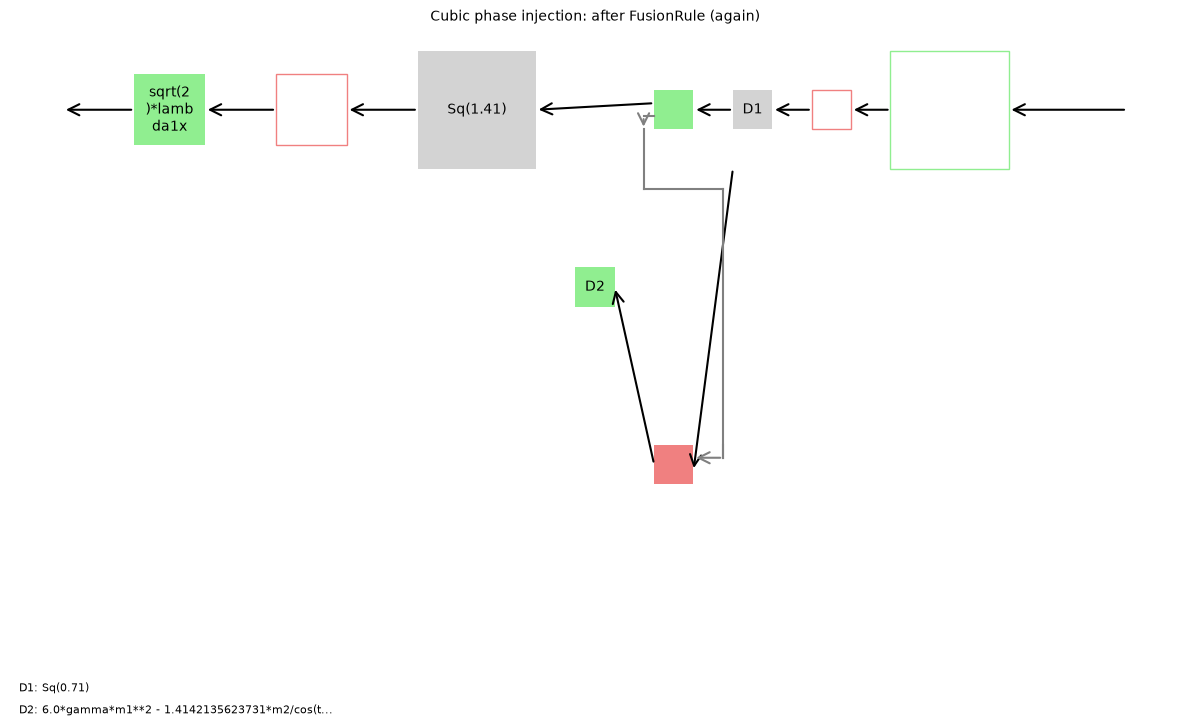

In [11]:
fusion_rule_again = FusionRule()
graph_after_fusion3 = to_graph(diag_after_absorption2)

fusion_rule_again.apply_rule(graph_after_fusion3)

diag_after_fusion3 = to_diagram(graph_after_fusion3)
fig_after_fusion3 = visualize(diag_after_fusion3, "Cubic phase injection: after FusionRule (again)")

### 6. VoidPortPruningRule

`normalize_diagram()` first re-flattens the Tensor/Compose nesting into canonical alternating stages, which is what puts the dead-ended ports VoidPortPruningRule needs directly next to their VoidDiagram in one flat Compose. `VoidPortPruningRule` then trims 2 of them away.


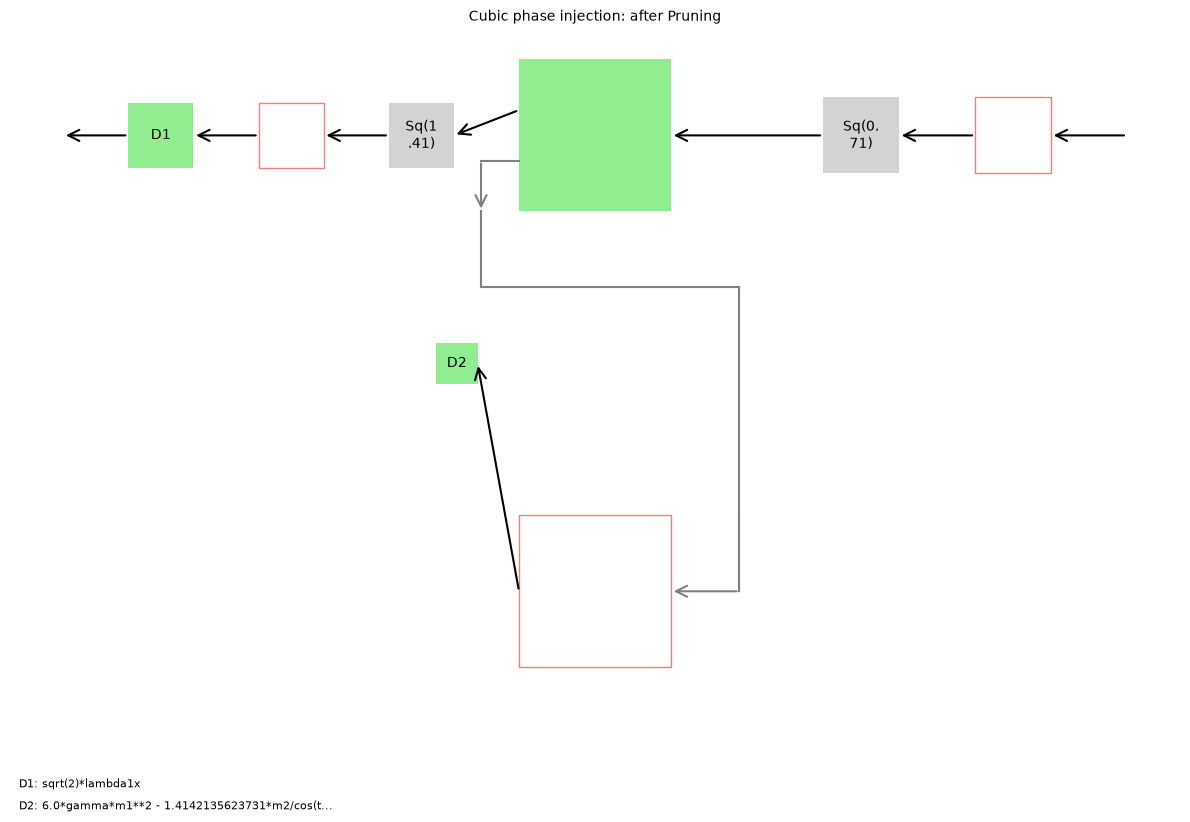

In [12]:
pruning_rule = VoidPortPruningRule()
graph_after_pruning = to_graph(normalize_diagram(diag_after_fusion3))
pruning_rule.apply_rule(graph_after_pruning)
diag_after_pruning = to_diagram(graph_after_pruning)
fig_after_pruning = visualize(diag_after_pruning, "Cubic phase injection: after Pruning")

### 7. TerminalAbsorptionRule

The pruning above exposes the LAST ContractedDiagram's own bare-terminal half (the $\gamma x^3$ cubic-phase correction) -- `bare_cap_fusion` folds it into the combined spider, which is where the full m1/theta1/m2-dependent polynomial first appears as a single spider.


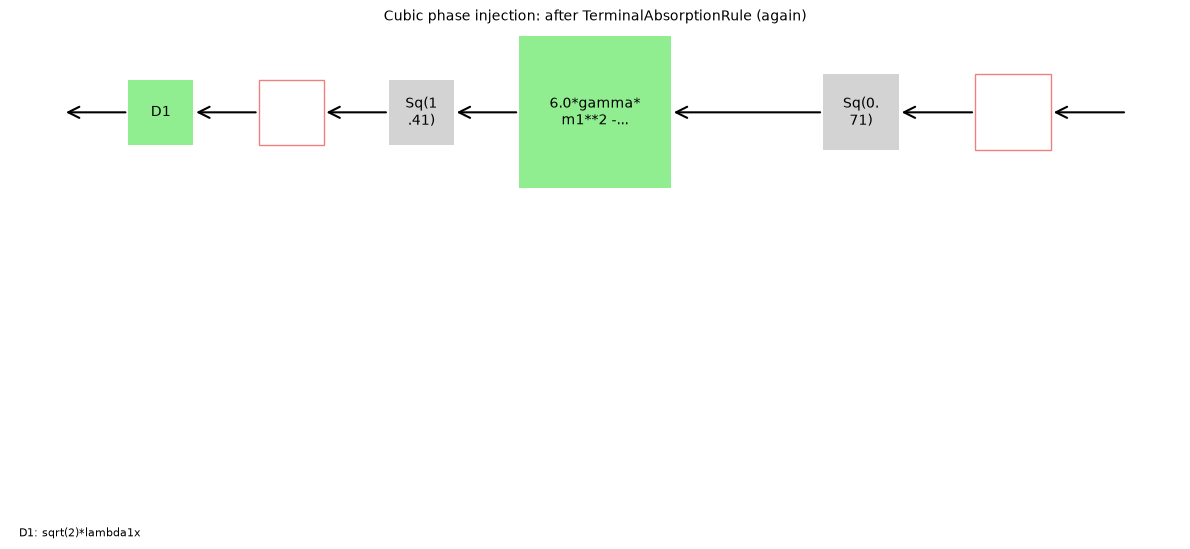

In [13]:
absorption_rule_again = TerminalAbsorptionRule(True)
graph_after_absorption3 = to_graph(diag_after_pruning)
absorption_rule_again.apply_rule(graph_after_absorption3)
diag_after_absorption3 = to_diagram(graph_after_absorption3)
fig_after_absorption3 = visualize(diag_after_absorption3, "Cubic phase injection: after TerminalAbsorptionRule (again)")

### 8. ChainReductionRule

`ChainReductionRule`'s commute-and-fuse: the last surviving SqueezingGate crosses the combined spider (scaling its phase's own variable), then fuses with the $\lambda_1$-carrying spider it lands next to -- `normalize_diagram()` first re-flattens so this pair are direct composition siblings again, same reason as in the `VoidPortPruningRule` step above. This is the final step: the result already matches the paper's claimed closed form (see the next cell, and compare against `diag_reduced` from the "paper's claimed reduced form" section above).



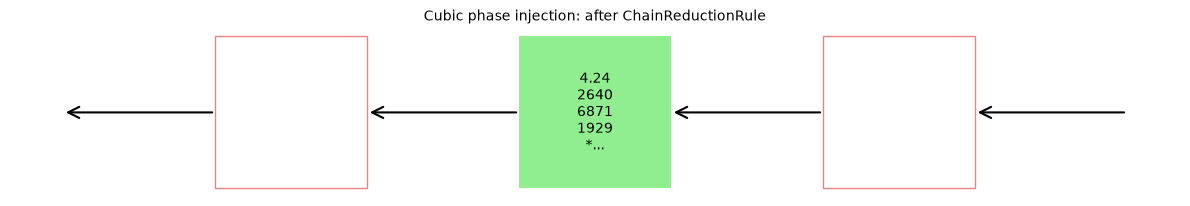

In [14]:
chain_rule = ChainReductionRule()
graph_after_chain_red = to_graph(normalize_diagram(diag_after_absorption3))

chain_rule.apply_rule(graph_after_chain_red)

diag_after_chain_red = to_diagram(graph_after_chain_red)
fig_after_chain_red = visualize(normalize_diagram(diag_after_chain_red), "Cubic phase injection: after ChainReductionRule")

The surviving spider's own phase, fully reduced: matches diag_reduced's predicted $\frac{\gamma}{2*sqrt(2)} x^3 + \alpha x^2 + \beta x$ form exactly (compare the printed coefficients below against the "paper's claimed reduced form" section above).


In [15]:
diag_after_chain_red.diagrams[0].diagrams[1].phase

4.24264068711929*gamma*m1**2 + 1.0*sqrt(2)*lambda1 - 1.0*m2/cos(theta1)·x + -2.12132034355964*gamma*m1 - 0.5*tan(theta1)·x^2 + 0.353553390593274*gamma·x^3

## Run the optimization pipeline

The same reduction, but automatically: `optimize()` loops every rewrite rule (including
`normalize_diagram()`between rounds) to a fixed point in one call, instead of the rule-by-rule walkthrough above.

`assume_infinite_squeezing=True` is what unlocks `CopyRule` and `TerminalAbsorptionRule` -- without it, this diagram can not be reduced to the result obtained in the paper.


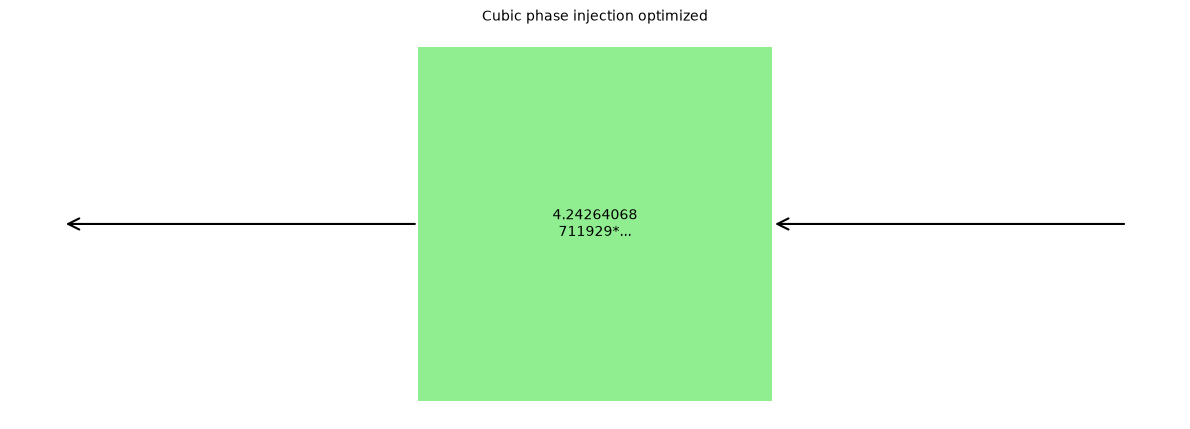

In [16]:
result = optimize(diag, assume_infinite_squeezing=True)
fig = visualize(result.diagram, "Cubic phase injection optimized")

Same fully-reduced phase as the incremental pipeline's own final cell above -- confirming `optimize()` and the rule-by-rule walkthrough agree exactly.


In [17]:
result.diagram.diagrams[0].phase

4.24264068711929*gamma*m1**2 + 1.0*sqrt(2)*lambda1 - 1.0*m2/cos(theta1)·x + -2.12132034355964*gamma*m1 - 0.5*tan(theta1)·x^2 + 0.353553390593274*gamma·x^3

## Metrics

A few numeric checks to complement the qualitative "the phases match" comparisons
above: how much the diagram itself shrinks under `optimize()`, whether the leading
(measurement-independent) cubic coefficient exactly matches the paper's closed form, and
whether the two graph backends agree on the result -- the property this repo's dual-backend
rewrite-rule work (see `CHANGELOG.md`) exists to guarantee.

### 1. Diagram-size reduction

Node/edge counts of the raw input diagram's graph vs. the fully `optimize()`d one.

In [18]:
from cvzx.backends.nx.graph import to_graph

initial_graph = to_graph(diag).graph
optimized_nx = optimize(diag, backend="networkx", assume_infinite_squeezing=True)
optimized_graph = optimized_nx.graph.graph

initial_nodes, initial_edges = initial_graph.number_of_nodes(), initial_graph.number_of_edges()
optimized_nodes, optimized_edges = optimized_graph.number_of_nodes(), optimized_graph.number_of_edges()

print(f"Initial diagram:   {initial_nodes} nodes, {initial_edges} edges")
print(f"Optimized diagram: {optimized_nodes} nodes, {optimized_edges} edges")
print(f"Node count reduced by {100 * (1 - optimized_nodes / initial_nodes):.0f}%")

Initial diagram:   37 nodes, 23 edges
Optimized diagram: 18 nodes, 6 edges
Node count reduced by 51%


### 2. Closed-form correctness

The paper's one parameter-independent, exactly-checkable claim: the surviving spider's
$x^3$ coefficient is exactly $\gamma / (2\sqrt{2})$, regardless of $m_1$, $m_2$, $\theta_1$,
$\lambda_1$. Compared numerically rather than symbolically, since the gadget's own
`SqueezingGate(sqrt(2))` (cell 3 above) mixes a floating-point `sqrt(2)` into the pipeline
against the predicted form's exact sympy one.

In [19]:
final_spider = optimized_nx.diagram.diagrams[0]
actual_x3_coeff = final_spider.phase.coeffs.get(3, 0)
predicted_x3_coeff = diag_reduced.phase.coeffs.get(3, 0)

error = abs(float(actual_x3_coeff.subs(gamma, 1)) - float(predicted_x3_coeff.subs(gamma, 1)))
print(f"Leading (gamma * x^3) coefficient -- actual: {actual_x3_coeff}, predicted: {predicted_x3_coeff}")
print(f"Absolute error: {error:.2e}")
assert error < 1e-9

Leading (gamma * x^3) coefficient -- actual: 0.353553390593274*gamma, predicted: sqrt(2)*gamma/4
Absolute error: 1.11e-16


### 3. Backend parity

Re-runs the same `optimize()` call on the `rustworkx` backend and checks it reaches the
*exact* same diagram as the `networkx` run above -- both graph backends must agree, not
just each converge to something matching the paper.

In [20]:
optimized_rx = optimize(diag, backend="rustworkx", assume_infinite_squeezing=True)

backends_agree = repr(optimized_nx.diagram) == repr(optimized_rx.diagram)
print("nx and rustworkx reach the exact same diagram:", backends_agree)
assert backends_agree

nx and rustworkx reach the exact same diagram: True
